# Phân tích Lỗi (Error Analysis) & Trực quan hóa (Grad-CAM)
Notebook này thực hiện 2 nhiệm vụ chính:
1. Lọc ra các ca dự đoán sai với độ tự tin cao nhất (Top-K Confident Mistakes) trên tập Test.
2. Sinh bản đồ nhiệt Grad-CAM từ khối Fusion cuối cùng để xem mô hình đang chú ý vào vùng không gian nào trên lá cây.

In [13]:
!pip install opencv-python

In [14]:
import os
import sys
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModel

current_dir = Path.cwd()
PROJECT_ROOT = current_dir
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.datasets.multimodal_raw_dataset import MultiModalRawDataset, multimodal_raw_collate_fn
from src.models.backbones.vision.convnext_cbam import ConvNeXt_CBAM
from src.models.fusion.mulco_fusion import MulCoFusionBlock

## 1. Định nghĩa Models và Dataloader

In [15]:
class MLPClassifier(nn.Module):
    def __init__(self, in_channels=512, hidden_dim=256, num_classes=28, dropout_rate=0.2):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(in_channels, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, num_classes)
        )
        
    def forward(self, x):
        x = self.pool(x)
        x = self.flatten(x)
        return self.net(x)

class MulCoEndToEnd(nn.Module):
    def __init__(self, num_classes=28, proj_dim=512):
        super().__init__()
        self.image_backbone = ConvNeXt_CBAM(num_classes=num_classes)
        self.text_backbone = AutoModel.from_pretrained("roberta-base")
        self.img_proj = nn.Conv2d(1024, proj_dim, kernel_size=1)
        self.txt_proj = nn.Linear(768, proj_dim)
        self.fusion_blocks = nn.ModuleList([
            MulCoFusionBlock(dim=proj_dim, num_heads=8) for _ in range(2)
        ])
        self.classifier = MLPClassifier(in_channels=proj_dim, hidden_dim=256, num_classes=num_classes, dropout_rate=0.2)

    def forward(self, images, input_ids, attention_mask):
        img_feat = self.image_backbone.forward_features_spatial(images)
        txt_out = self.text_backbone(input_ids=input_ids, attention_mask=attention_mask)
        txt_feat = txt_out.last_hidden_state
        img_feat = self.img_proj(img_feat)
        txt_feat = self.txt_proj(txt_feat)
        for block in self.fusion_blocks:
            img_feat, txt_feat = block(img_feat, txt_feat, attention_mask)
        logits = self.classifier(img_feat)
        return logits

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dir = PROJECT_ROOT / "data/processed/PlantDocSplited_depth_AUG/test"
caption_dir = PROJECT_ROOT / "data/AIDG/captions_LLaVA"
mapping_path = PROJECT_ROOT / "data/processed/PlantDocSplited_depth_AUG/global_image_caption_mapping.json"

test_dataset = MultiModalRawDataset(
    image_root=test_dir,
    caption_root=caption_dir,
    transform=test_transform,
    use_depth_suppressed=False,
    strict_caption_match=False,
    image_caption_mapping_path=str(mapping_path)
)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4, collate_fn=multimodal_raw_collate_fn)
idx_to_class = test_dataset.idx_to_class

model = MulCoEndToEnd(num_classes=28).to(device)
ckpt_path = PROJECT_ROOT / "archive/mulco_depth_aug_cb_focal_mlp/best_fine_tuned_model.pth"
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True), strict=True)
text_tokenizer = AutoTokenizer.from_pretrained("roberta-base")
print("Model and Data Loaded!")

[MultiModalRawDataset] Loaded image-caption mapping: 5256 entries
[MultiModalRawDataset] Total selected images: 250
[MultiModalRawDataset] Valid samples: 250
[MultiModalRawDataset] Skipped missing caption: 0
[MultiModalRawDataset] Skipped invalid caption: 0
[MultiModalRawDataset] Matched by external mapping: 250
[MultiModalRawDataset] Num classes: 28
[MultiModalRawDataset] class_to_idx: {'Apple_Scab_Leaf': 0, 'Apple_leaf': 1, 'Apple_rust_leaf': 2, 'Bell_pepper_leaf': 3, 'Bell_pepper_leaf_spot': 4, 'Blueberry_leaf': 5, 'Cherry_leaf': 6, 'Corn_Gray_leaf_spot': 7, 'Corn_leaf_blight': 8, 'Corn_rust_leaf': 9, 'Peach_leaf': 10, 'Potato_leaf_early_blight': 11, 'Potato_leaf_late_blight': 12, 'Raspberry_leaf': 13, 'Soyabean_leaf': 14, 'Squash_Powdery_mildew_leaf': 15, 'Strawberry_leaf': 16, 'Tomato_Early_blight_leaf': 17, 'Tomato_Septoria_leaf_spot': 18, 'Tomato_leaf': 19, 'Tomato_leaf_bacterial_spot': 20, 'Tomato_leaf_late_blight': 21, 'Tomato_leaf_mosaic_virus': 22, 'Tomato_leaf_yellow_virus'

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model and Data Loaded!


## 2. Tìm kiếm Top-K Lỗi sai tự tin nhất (Error Analysis)

In [17]:
errors = []
model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Finding Mistakes"):
        images = batch["image"].to(device)
        texts = batch["text"]
        labels = batch["label"].to(device)
        image_paths = batch["image_path"]
        
        text_tokens = text_tokenizer(texts, padding=True, truncation=True, max_length=256, return_tensors="pt")
        input_ids = text_tokens.input_ids.to(device)
        attention_mask = text_tokens.attention_mask.to(device)

        # Áp dụng TTA để khớp với kết quả Test Accuracy đã ghi nhận
        logits_orig = model(images, input_ids, attention_mask)
        logits_hflip = model(torch.flip(images, dims=[3]), input_ids, attention_mask)
        logits = (logits_orig + logits_hflip) / 2.0
        
        probs = F.softmax(logits, dim=1)
        max_probs, preds = torch.max(probs, dim=1)
        
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                errors.append({
                    "image_path": image_paths[i],
                    "text": texts[i],
                    "true_label": labels[i].item(),
                    "pred_label": preds[i].item(),
                    "confidence": max_probs[i].item()
                })

# Sắp xếp giảm dần theo độ tự tin (Những ca mô hình "cãi cố" tự tin sai nhất)
errors = sorted(errors, key=lambda x: x["confidence"], reverse=True)
print(f"Tổng số ảnh dự đoán sai: {len(errors)}")

Finding Mistakes:   0%|          | 0/16 [00:00<?, ?it/s]

Tổng số ảnh dự đoán sai: 34


## 3. Trực quan hóa Grad-CAM cho Top 5 ảnh sai

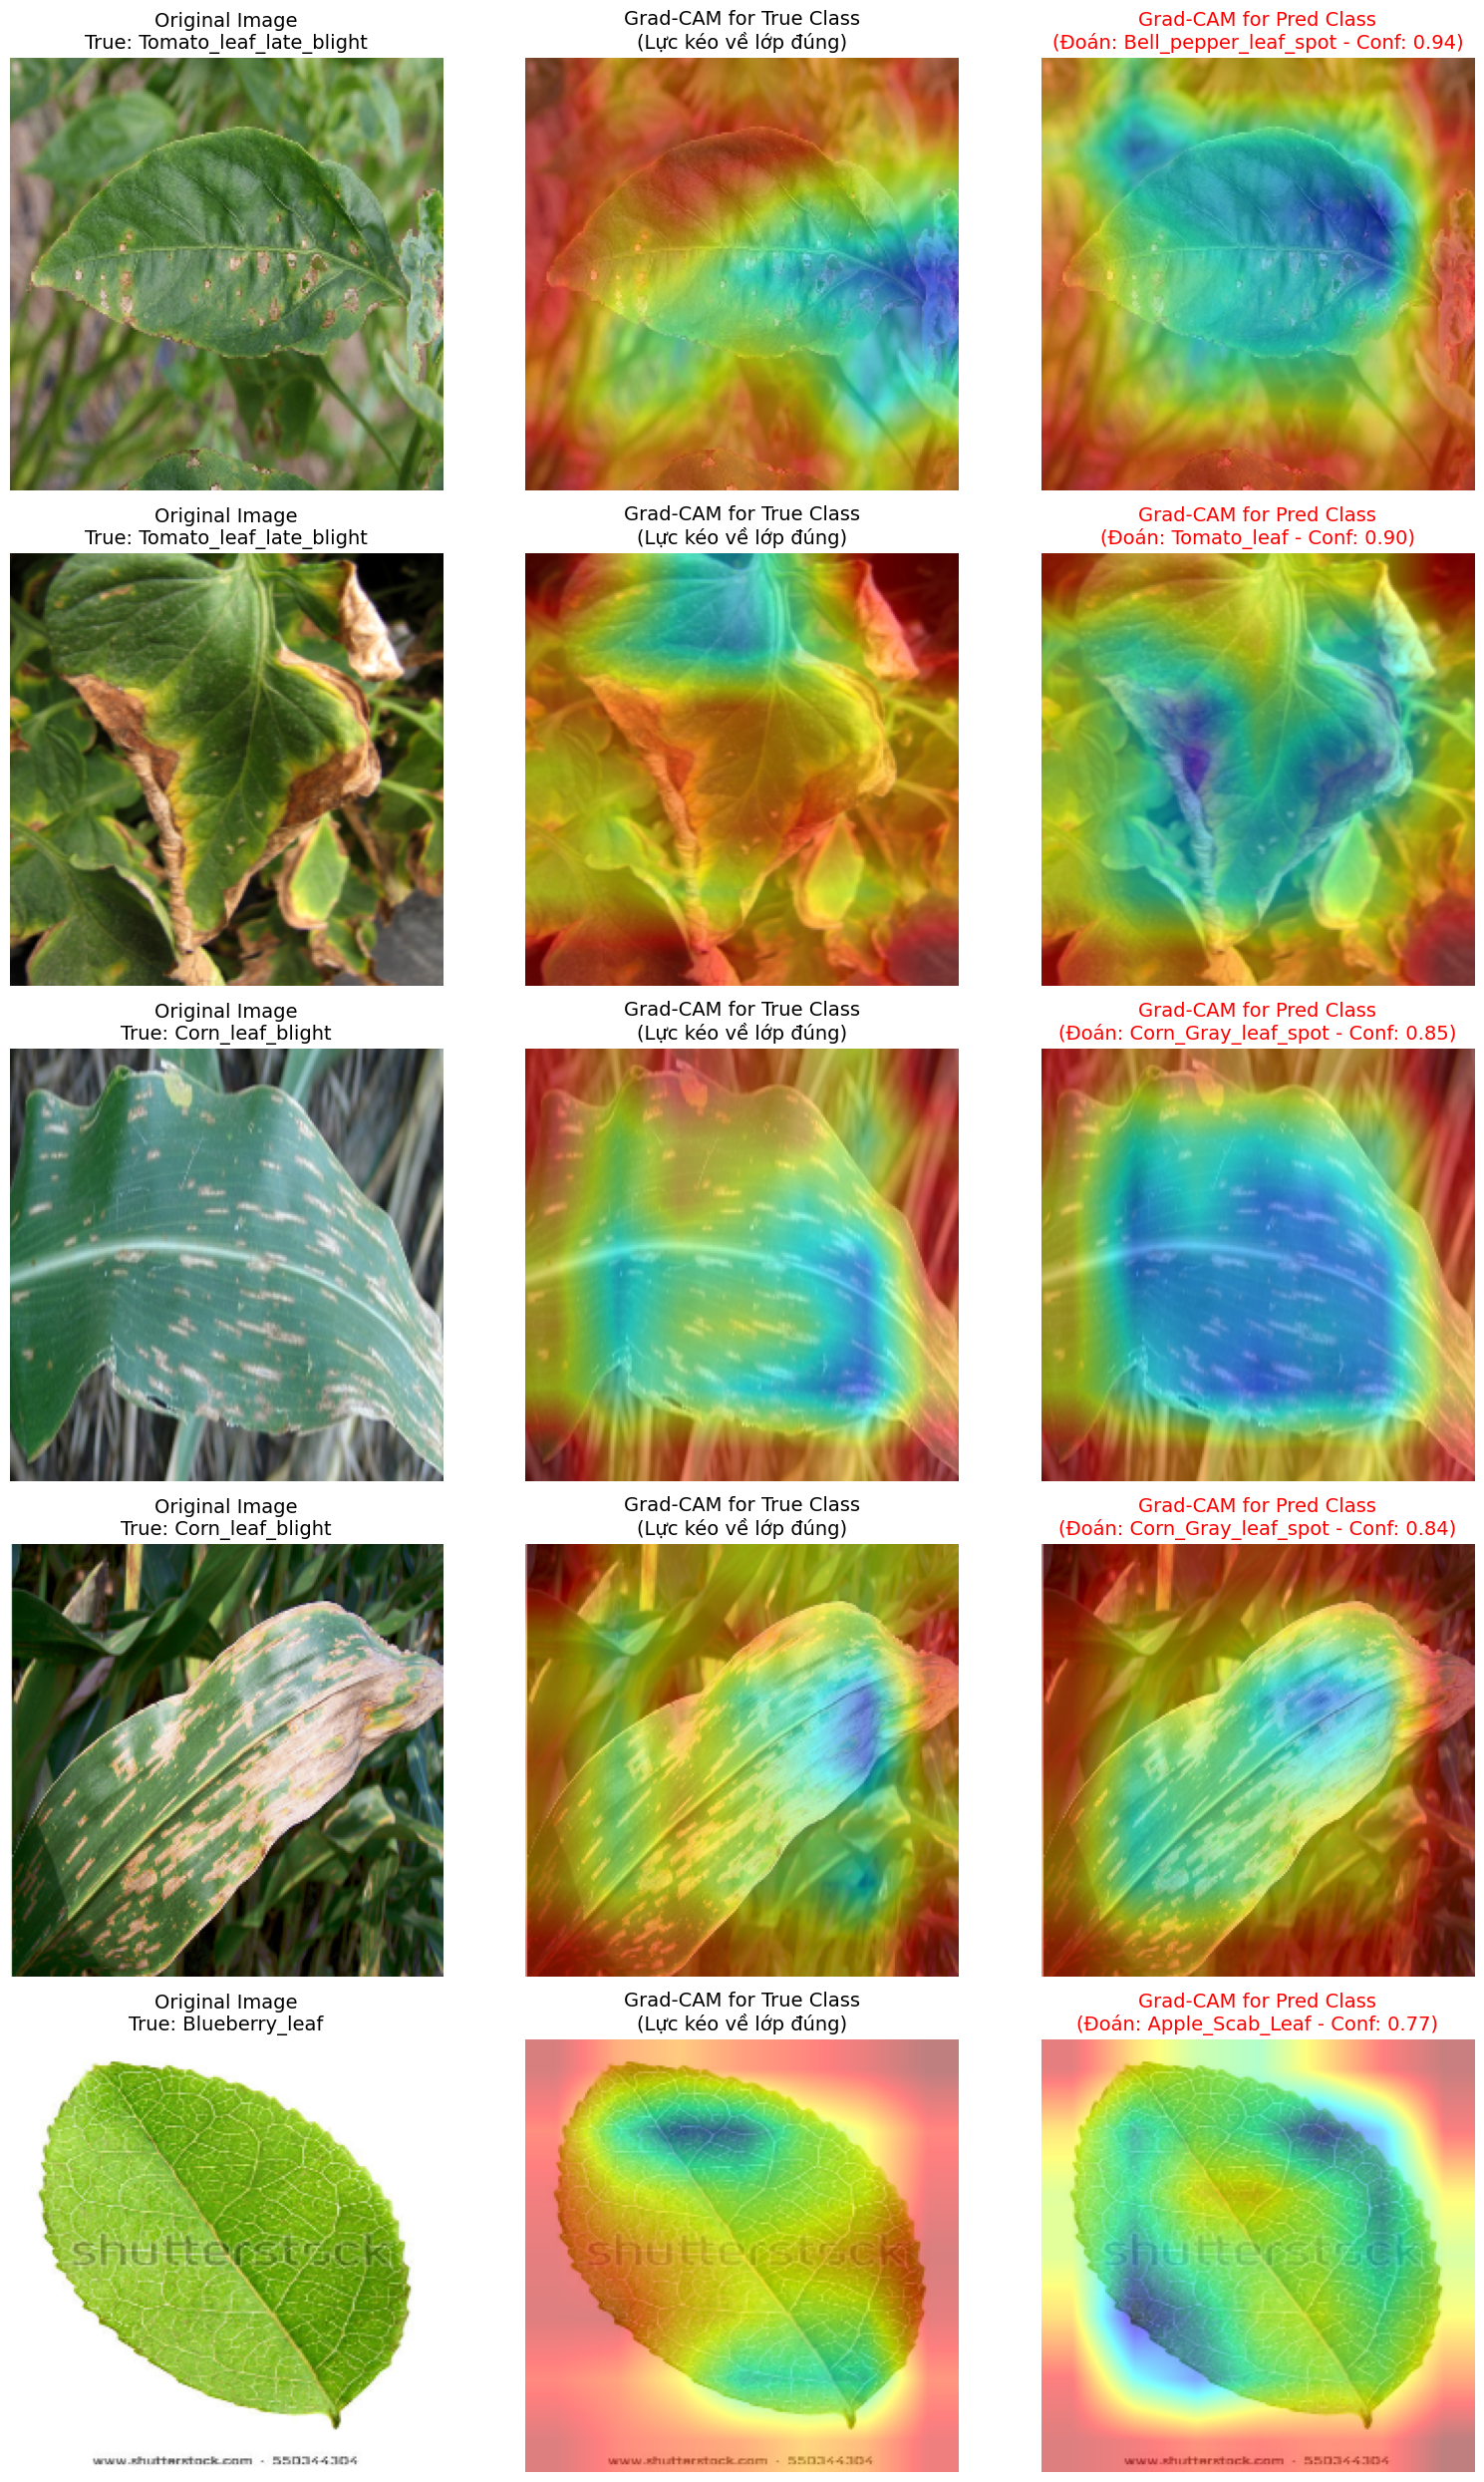

In [18]:
def generate_gradcam(model, image_path, text, target_class):
    model.eval()
    img_pil = cv2.imread(image_path)
    img_pil = cv2.cvtColor(img_pil, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_pil, (224, 224))
    img_tensor = test_transform(Image.fromarray(img_resized)).unsqueeze(0).to(device)
    
    text_tokens = text_tokenizer([text], padding=True, truncation=True, max_length=256, return_tensors="pt")
    
    # Forward thủ công từng bước để bắt gradient tại Fusion block
    img_feat = model.image_backbone.forward_features_spatial(img_tensor)
    txt_out = model.text_backbone(input_ids=text_tokens.input_ids.to(device), attention_mask=text_tokens.attention_mask.to(device))
    txt_feat = txt_out.last_hidden_state
    img_feat = model.img_proj(img_feat)
    txt_feat = model.txt_proj(txt_feat)
    
    for block in model.fusion_blocks:
        img_feat, txt_feat = block(img_feat, txt_feat, text_tokens.attention_mask.to(device))
        
    # Tách img_feat khỏi đồ thị phía trước và bật cờ theo dõi Gradient
    img_feat = img_feat.detach()
    img_feat.requires_grad = True
    logits = model.classifier(img_feat)
    
    model.zero_grad()
    score = logits[0, target_class]
    score.backward()
    
    # Tính toán Heatmap
    gradients = img_feat.grad[0] # [C, H, W]
    features = img_feat[0].detach() # [C, H, W]
    alpha = torch.mean(gradients, dim=[1, 2], keepdim=True) # GAP qua không gian
    cam = torch.sum(alpha * features, dim=0)
    cam = F.relu(cam)
    
    # Normalize 0-1
    cam_min, cam_max = cam.min(), cam.max()
    if cam_max > 0: cam = (cam - cam_min) / cam_max
    else: cam = torch.zeros_like(cam)
    
    cam = cam.cpu().numpy()
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255.0
    img_float = np.float32(img_resized) / 255.0
    
    cam_result = heatmap + img_float
    cam_result = cam_result / np.max(cam_result)
    return np.uint8(255 * cam_result), img_resized

# Vẽ biểu đồ cho 5 ảnh sai tự tin nhất
top_errors = errors[:5]
fig, axes = plt.subplots(len(top_errors), 3, figsize=(16, 5 * len(top_errors)))

for i, err in enumerate(top_errors):
    img_path = err["image_path"]
    text = err["text"]
    true_idx = err["true_label"]
    pred_idx = err["pred_label"]
    
    cam_true, img_orig = generate_gradcam(model, img_path, text, true_idx)
    cam_pred, _ = generate_gradcam(model, img_path, text, pred_idx)
    
    axes[i, 0].imshow(img_orig)
    axes[i, 0].set_title(f"Original Image\nTrue: {idx_to_class[true_idx]}", fontsize=14)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cam_true)
    axes[i, 1].set_title(f"Grad-CAM for True Class\n(Lực kéo về lớp đúng)", fontsize=14)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(cam_pred)
    axes[i, 2].set_title(f"Grad-CAM for Pred Class\n(Đoán: {idx_to_class[pred_idx]} - Conf: {err['confidence']:.2f})", fontsize=14, color='red')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()